# Stock Level Visualisation
Fetches **all products** from the running Django backend (`http://localhost:8000/inventory/products/`) using cursor-based pagination, then visualises **Current Quantity** vs **Minimum Stock Level** per product with Matplotlib and Seaborn.

## 1. Import Required Libraries

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

Libraries loaded.


## 2. Fetch All Products from the Backend
Calls `GET /inventory/products/?page_size=100` and follows `next` cursor links until all pages are exhausted.  

In [ ]:
BASE_URL = "http://localhost:8000/inventory/products/"
PAGE_SIZE = 100

all_products = []
url = f"{BASE_URL}?page_size={PAGE_SIZE}"

while url:
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json()
    all_products.extend(data.get("results", []))
    url = data.get("next")

df = pd.DataFrame(all_products)[["name", "quantity", "minimum_stock_level"]]
df["quantity"] = pd.to_numeric(df["quantity"])
df["minimum_stock_level"] = pd.to_numeric(df["minimum_stock_level"])
df["below_minimum"] = df["quantity"] < df["minimum_stock_level"]

print(f"Fetched {len(df)} products.")
df

Fetched 39 products.


,name,quantity,minimum_stock_level,below_minimum
0,Missing Barcode,10,2,False
1,Whitespace Name,15,2,False
2,Long Description,5,1,False
3,Zero Quantity,0,5,True
4,Invalid Barcode,10,2,False
5,Missing Barcode,10,2,False
6,Office Desk,10,1,False
7,Gaming Chair,20,2,False
8,USB Cable,300,30,False
9,Apple MacBook Sleeve,60,10,False


## 3. Grouped Bar Chart

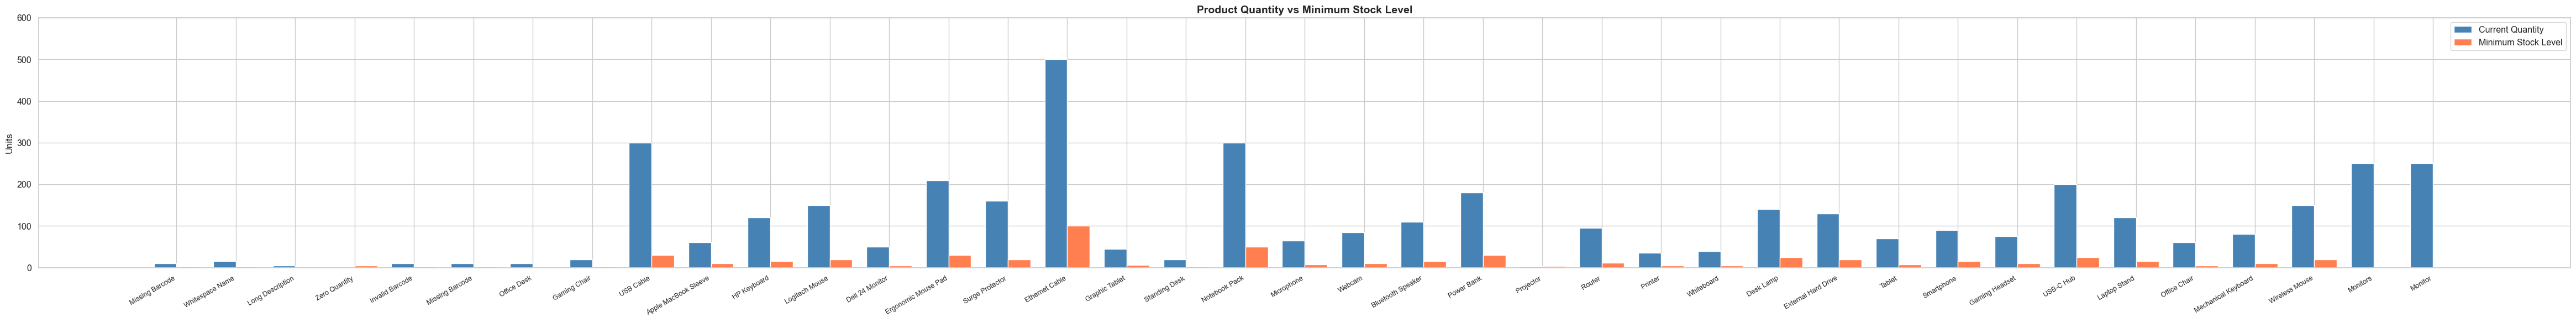

In [13]:
products = df["name"].tolist()
x = np.arange(len(products))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(max(10, len(products) * 1.2), 6))

ax.bar(x - bar_width / 2, df["quantity"], width=bar_width,
       label="Current Quantity", color="steelblue")
ax.bar(x + bar_width / 2, df["minimum_stock_level"], width=bar_width,
       label="Minimum Stock Level", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(products, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Units", fontsize=12)
ax.set_title("Product Quantity vs Minimum Stock Level", fontsize=14, fontweight="bold")
ax.legend()
ax.set_ylim(0, max(df["quantity"].max(), df["minimum_stock_level"].max()) * 1.2)

plt.tight_layout()
plt.show()